In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)

In [2]:
DATA_DIR = "../../Datasets_MLmodels/Chosen_Datasets/book_data"

OUTPUT_DIR = "../../outputs"
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")
RECOMMENDATION_DIR = os.path.join(OUTPUT_DIR, "recommendations")
EVALUATION_DIR = os.path.join(OUTPUT_DIR, "evaluation")

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(RECOMMENDATION_DIR, exist_ok=True)
os.makedirs(EVALUATION_DIR, exist_ok=True)

books_path = os.path.join(DATA_DIR, "books.csv")
ratings_path = os.path.join(DATA_DIR, "ratings.csv")
to_read_path = os.path.join(DATA_DIR, "to_read.csv")

In [3]:
books = pd.read_csv(books_path)
ratings = pd.read_csv(ratings_path)
to_read = pd.read_csv(to_read_path)

print("Books shape:", books.shape)
print("Ratings shape:", ratings.shape)
print("To-read shape:", to_read.shape)

Books shape: (10000, 9)
Ratings shape: (981756, 3)
To-read shape: (912705, 2)


In [4]:
print("BOOKS COLUMNS")
print(books.columns.tolist())

print("\nRATINGS COLUMNS")
print(ratings.columns.tolist())

print("\nTO_READ COLUMNS")
print(to_read.columns.tolist())

BOOKS COLUMNS
['Unnamed: 0', 'ISBN', 'book_id', 'Publication Year', 'Author', 'Title', 'AvgRating', 'Image-URL', 'Image-URL-S']

RATINGS COLUMNS
['book_id', 'user_id', 'rating']

TO_READ COLUMNS
['user_id', 'book_id']


In [5]:
display(books.head())
display(ratings.head())
display(to_read.head())

,Unnamed: 0,ISBN,book_id,Publication Year,Author,Title,AvgRating,Image-URL,Image-URL-S
0,0,0195153448,1,2008,Suzanne Collins,"The Hunger Games (The Hunger Games, #1)",4.34,https://images.gr-assets.com/books/1447303603m/2767052.jpg,https://images.gr-assets.com/books/1447303603s/2767052.jpg
1,1,0002005018,2,1997,"J.K. Rowling, Mary GrandPré","Harry Potter and the Sorcerer's Stone (Harry Potter, #1)",4.44,https://images.gr-assets.com/books/1474154022m/3.jpg,https://images.gr-assets.com/books/1474154022s/3.jpg
2,2,0060973129,3,2005,Stephenie Meyer,"Twilight (Twilight, #1)",3.57,https://images.gr-assets.com/books/1361039443m/41865.jpg,https://images.gr-assets.com/books/1361039443s/41865.jpg
3,3,0374157065,4,1960,Harper Lee,To Kill a Mockingbird,4.25,https://images.gr-assets.com/books/1361975680m/2657.jpg,https://images.gr-assets.com/books/1361975680s/2657.jpg
4,4,0393045218,5,1925,F. Scott Fitzgerald,The Great Gatsby,3.89,https://images.gr-assets.com/books/1490528560m/4671.jpg,https://images.gr-assets.com/books/1490528560s/4671.jpg


,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4


,user_id,book_id
0,1,112
1,1,235
2,1,533
3,1,1198
4,1,1874


In [6]:
required_book_columns = {
    "book_id", "Title", "Author", "AvgRating", "ratings_count"
}
required_rating_columns = {
    "user_id", "book_id", "rating"
}
required_to_read_columns = {
    "user_id","book_id"
}

missing_books = required_book_columns - set(books.columns)
missing_ratings = required_rating_columns - set(ratings.columns)
missing_to_read = required_to_read_columns - set(to_read.columns)

print("Missing book columns:", missing_books)
print("Missing rating columns:", missing_ratings)
print("Missing to-read columns:", missing_to_read)

Missing book columns: {'ratings_count'}
Missing rating columns: set()
Missing to-read columns: set()


In [7]:
print("========== BOOKS ==========")
books.info()

print("\n========== RATINGS ==========")
ratings.info()

print("\n========== TO READ ==========")
to_read.info()

========== BOOKS ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        10000 non-null  int64  
 1   ISBN              10000 non-null  object 
 2   book_id           10000 non-null  int64  
 3   Publication Year  10000 non-null  int64  
 4   Author            10000 non-null  object 
 5   Title             10000 non-null  object 
 6   AvgRating         10000 non-null  float64
 7   Image-URL         10000 non-null  object 
 8   Image-URL-S       10000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 703.3+ KB

========== RATINGS ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981756 entries, 0 to 981755
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   book_id  981756 non-null  int64
 1   user_id  981756 non-null  i

In [8]:
print("Missing values in books:")
display(
    books.isnull().sum().sort_values(ascending=False).to_frame("missing_values"))

print("\nMissing values in ratings:")
display(
    ratings.isnull().sum().sort_values(ascending=False).to_frame("missing_values"))

print("\nMissing values in to_read:")
display(
    to_read.isnull().sum().sort_values(ascending=False).to_frame("missing_values"))

Missing values in books:


,missing_values
Unnamed: 0,0
ISBN,0
book_id,0
Publication Year,0
Author,0
Title,0
AvgRating,0
Image-URL,0
Image-URL-S,0



Missing values in ratings:


,missing_values
book_id,0
user_id,0
rating,0



Missing values in to_read:


,missing_values
user_id,0
book_id,0


In [9]:
print("Duplicate book rows:", books.duplicated().sum())
print("Duplicate rating rows:", ratings.duplicated().sum())
print("Duplicate to-read rows:", to_read.duplicated().sum())

print(
    "Duplicate user-book rating pairs:",
    ratings.duplicated(subset=["user_id", "book_id"]).sum()
)

print(
    "Duplicate user-book to-read pairs:",
    to_read.duplicated(subset=["user_id", "book_id"]).sum()
)

Duplicate book rows: 0
Duplicate rating rows: 1644
Duplicate to-read rows: 0
Duplicate user-book rating pairs: 2278
Duplicate user-book to-read pairs: 0


In [10]:
books = books.drop_duplicates().copy()

ratings = ratings.drop_duplicates(subset=["user_id", "book_id"]).copy()

to_read = to_read.drop_duplicates(subset=["user_id", "book_id"]).copy()

In [11]:
print("Minimum rating:", ratings["rating"].min())
print("Maximum rating:", ratings["rating"].max())

print("\nRating distribution:")
display(ratings["rating"].value_counts().sort_index())

Minimum rating: 1
Maximum rating: 5

Rating distribution:


rating
1     19530
2     63116
3    248144
4    356620
5    292068
Name: count, dtype: int64

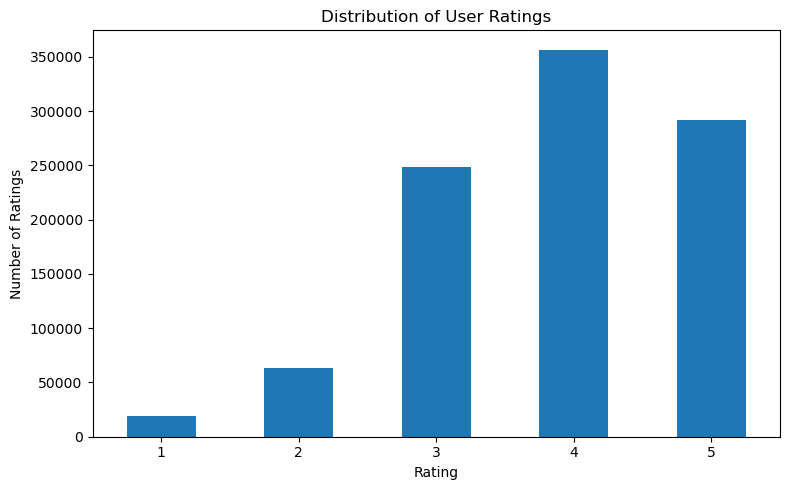

In [12]:
plt.figure(figsize=(8, 5))

ratings["rating"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribution of User Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "rating_distribution.png"),
    dpi=300
)

plt.show()

In [13]:
num_users = ratings["user_id"].nunique()
num_books = ratings["book_id"].nunique()
num_ratings = len(ratings)

print("Number of users:", num_users)
print("Number of books:", num_books)
print("Number of ratings:", num_ratings)

Number of users: 53424
Number of books: 10000
Number of ratings: 979478


In [14]:
total_possible_ratings = num_users * num_books

sparsity = (
    1 - (num_ratings / total_possible_ratings)
)
print(f"Rating matrix sparsity: {sparsity:.4%}")

Rating matrix sparsity: 99.8167%


In [15]:
most_rated = (
    ratings
    .groupby("book_id")
    .size()
    .reset_index(name="rating_count")
    .merge(books[["book_id", "Title", "Author"]], on="book_id", how="left")
    .sort_values("rating_count", ascending=False)
)

display(most_rated.head(20))

,book_id,rating_count,Title,Author
0,1,100,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins
4930,4931,100,At the Mountains of Madness and Other Tales of Terror,H.P. Lovecraft
4926,4927,100,"Red: The Heroic Rescue (The Circle, #2)",Ted Dekker
4924,4925,100,Nation,Terry Pratchett
4921,4922,100,"Whispers Under Ground (Peter Grant, #3)",Ben Aaronovitch
4919,4920,100,Testimony,Anita Shreve
4916,4917,100,"The Bourne Objective (Jason Bourne, #8)","Eric Van Lustbader, Robert Ludlum"
4914,4915,100,"Night Fall (John Corey, #3)",Nelson DeMille
4909,4910,100,Just Like Heaven (Smythe-Smith Quartet #1),Julia Quinn
4908,4909,100,"N is for Noose (Kinsey Millhone, #14)",Sue Grafton


In [16]:
book_stats = (
    ratings.groupby("book_id").agg(
        user_rating_count=("rating", "count"),
        user_average_rating=("rating", "mean")
    )
    .reset_index()
)
book_stats = book_stats.merge(
    books[["book_id", "Title", "Author", "AvgRating"]],
    on="book_id", how="left"
)

In [17]:
C = book_stats["user_average_rating"].mean()
m = book_stats["user_rating_count"].quantile(0.90)

book_stats["popularity_score"] = (
    (
        book_stats["user_rating_count"] /
        ( book_stats["user_rating_count"] + m)
    ) *
    book_stats["user_average_rating"] +
    ( 
        m /
        (
            book_stats["user_rating_count"] + m
        )
    ) * C
)

In [18]:
popular_books = (
    book_stats.sort_values("popularity_score", ascending=False).head(20)
)
display(
    popular_books[
        ["book_id", "Title", "Author", 
         "user_rating_count", "user_average_rating",
         "popularity_score"]
    ]
)

,book_id,Title,Author,user_rating_count,user_average_rating,popularity_score
6919,6920,The Indispensable Calvin and Hobbes,Bill Watterson,99,4.777778,4.314939
5206,5207,The Days Are Just Packed: A Calvin and Hobbes Collection,Bill Watterson,99,4.777778,4.314939
9565,9566,Attack of the Deranged Mutant Killer Monster Snow Goons,Bill Watterson,99,4.777778,4.314939
6360,6361,There's Treasure Everywhere: A Calvin and Hobbes Collection,Bill Watterson,100,4.770000,4.313364
3274,3275,"Harry Potter Boxed Set, Books 1-5 (Harry Potter, #1-5)","J.K. Rowling, Mary GrandPré",100,4.770000,4.313364
5579,5580,The Calvin and Hobbes Lazy Sunday Book,Bill Watterson,100,4.750000,4.303364
4482,4483,It's a Magical World: A Calvin and Hobbes Collection,Bill Watterson,100,4.750000,4.303364
6589,6590,The Authoritative Calvin and Hobbes: A Calvin and Hobbes Treasury,Bill Watterson,100,4.750000,4.303364
7946,7947,ESV Study Bible,"Anonymous, Lane T. Dennis, Wayne A. Grudem",87,4.816092,4.303063
1307,1308,"A Court of Mist and Fury (A Court of Thorns and Roses, #2)",Sarah J. Maas,99,4.737374,4.294838


In [19]:
popular_books.to_csv(
    os.path.join(
        RECOMMENDATION_DIR, "popularity_recommendations.csv"), index=False)

In [20]:
content_columns = []
for column in [
    "Title",
    "Author",
    "original_title",
    "language_code",
    "original_publication_year"
]:
    if column in books.columns:
        content_columns.append(column)
content_columns

['Title', 'Author']

In [21]:
books["content"] = ""
for column in content_columns:
    books["content"] += (books[column].fillna("").astype(str)+ " ")

books["content"] = (
    books["content"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
)
display(
    books[["book_id", "Title", "Author", "content"]].head()
)

,book_id,Title,Author,content
0,1,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,"the hunger games (the hunger games, #1) suzanne collins"
1,2,"Harry Potter and the Sorcerer's Stone (Harry Potter, #1)","J.K. Rowling, Mary GrandPré","harry potter and the sorcerer's stone (harry potter, #1) j.k. rowling, mary grandpré"
2,3,"Twilight (Twilight, #1)",Stephenie Meyer,"twilight (twilight, #1) stephenie meyer"
3,4,To Kill a Mockingbird,Harper Lee,to kill a mockingbird harper lee
4,5,The Great Gatsby,F. Scott Fitzgerald,the great gatsby f. scott fitzgerald


In [22]:
tfidf = TfidfVectorizer(stop_words="english", max_features=20000, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(books["content"])

print("TF-IDF matrix shape:")
print(tfidf_matrix.shape)

TF-IDF matrix shape:
(10000, 20000)


In [23]:
book_index = pd.Series(books.index, index=books["book_id"]).drop_duplicates()

In [24]:
title_index = pd.Series(books.index, index=books["Title"].str.lower()).drop_duplicates()

In [28]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_content(book_id, n=10):
    if book_id not in book_index:
        return pd.DataFrame()
    
    idx = book_index[book_id]
    similarity_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    
    similarity_indices = np.argsort(similarity_scores)[::-1]
    
    similarity_indices = [i for i in similarity_indices if i != idx][:n]
    
    result = books.iloc[similarity_indices][
        ["book_id", "Title", "Author"]].copy()
    
    result["content_score"] = (similarity_scores[similarity_indices])
    return result

In [29]:
books[
    books["Title"]
    .str.contains("Harry Potter", case=False, na=False
    )
][["book_id", "Title", "Author"]].head(10)

,book_id,Title,Author
1,2,"Harry Potter and the Sorcerer's Stone (Harry Potter, #1)","J.K. Rowling, Mary GrandPré"
17,18,"Harry Potter and the Prisoner of Azkaban (Harry Potter, #3)","J.K. Rowling, Mary GrandPré, Rufus Beck"
20,21,"Harry Potter and the Order of the Phoenix (Harry Potter, #5)","J.K. Rowling, Mary GrandPré"
22,23,"Harry Potter and the Chamber of Secrets (Harry Potter, #2)","J.K. Rowling, Mary GrandPré"
23,24,"Harry Potter and the Goblet of Fire (Harry Potter, #4)","J.K. Rowling, Mary GrandPré"
24,25,"Harry Potter and the Deathly Hallows (Harry Potter, #7)","J.K. Rowling, Mary GrandPré"
26,27,"Harry Potter and the Half-Blood Prince (Harry Potter, #6)","J.K. Rowling, Mary GrandPré"
278,279,"Harry Potter and the Cursed Child - Parts One and Two (Harry Potter, #8)","John Tiffany, Jack Thorne, J.K. Rowling"
421,422,"Harry Potter Boxset (Harry Potter, #1-7)",J.K. Rowling
2000,2001,Harry Potter: Film Wizardry,Brian Sibley


In [30]:
sample_book_id = books.iloc[0]["book_id"]

recommend_content(sample_book_id, n=10)

,book_id,Title,Author,content_score
506,507,"The Hunger Games Trilogy Boxset (The Hunger Games, #1-3)",Suzanne Collins,0.875416
16,17,"Catching Fire (The Hunger Games, #2)",Suzanne Collins,0.826895
19,20,"Mockingjay (The Hunger Games, #3)",Suzanne Collins,0.755882
6223,6224,The World of the Hunger Games (Hunger Games Trilogy),Kate Egan,0.709120
1354,1355,The Hunger Games Tribute Guide,Emily Seife,0.595831
716,717,The Hunger Games: Official Illustrated Movie Companion,Kate Egan,0.386251
3953,3954,Hunger,"Knut Hamsun, George Egerton",0.379582
8576,8577,The Girl Who Was on Fire: Your Favorite Authors on Suzanne Collins' Hunger Games Trilogy,"Leah Wilson, Jennifer Lynn Barnes, Mary Borsellino, Sarah Rees Brennan, Terri Clark, Bree Despa...",0.276305
7095,7096,The Other Typist,Suzanne Rindell,0.226761
5945,5946,"The Quillan Games (Pendragon, #7)",D.J. MacHale,0.220341


In [31]:
MIN_USER_RATINGS = 5

user_counts = (ratings["user_id"].value_counts())

eligible_users = user_counts[user_counts >= MIN_USER_RATINGS].index

ratings_cf = ratings[ratings["user_id"].isin(eligible_users)].copy()

print("Original ratings:", len(ratings))
print("Filtered ratings:", len(ratings_cf))
print(
    "Users remaining:",
    ratings_cf["user_id"].nunique()
)

Original ratings: 979478
Filtered ratings: 930605
Users remaining: 35659


In [32]:
MIN_BOOK_RATINGS = 5

book_counts = (ratings_cf["book_id"].value_counts())

eligible_books = book_counts[book_counts >= MIN_BOOK_RATINGS].index

ratings_cf = ratings_cf[ratings_cf["book_id"].isin(eligible_books)].copy()

print("Ratings:", len(ratings_cf))
print("Users:", ratings_cf["user_id"].nunique())
print("Books:", ratings_cf["book_id"].nunique())

Ratings: 930605
Users: 35659
Books: 10000


In [33]:
train_ratings, test_ratings = train_test_split(
    ratings_cf,
    test_size=0.20,
    random_state=42
)

print("Training ratings:", len(train_ratings))
print("Testing ratings:", len(test_ratings))

Training ratings: 744484
Testing ratings: 186121


In [34]:
user_ids = train_ratings["user_id"].unique()
book_ids = train_ratings["book_id"].unique()

user_to_index = {
    user_id: index
    for index, user_id in enumerate(user_ids)
}
book_to_index = {
    book_id: index
    for index, book_id in enumerate(book_ids)
}
index_to_user = {
    index: user_id
    for user_id, index in user_to_index.items()
}
index_to_book = {
    index: book_id
    for book_id, index in book_to_index.items()
}

In [35]:
rows = train_ratings["user_id"].map(user_to_index)
cols = train_ratings["book_id"].map(book_to_index)

data = train_ratings["rating"].astype(float)

user_item_matrix = csr_matrix(
    (
        data, (rows, cols)
    ),
    shape=(len(user_to_index), len(book_to_index)
    )
)
print("User-item matrix:", user_item_matrix.shape)

User-item matrix: (35655, 10000)


In [36]:
N_COMPONENTS = 50
svd = TruncatedSVD(
    n_components=N_COMPONENTS,
    random_state=42
)

user_factors = svd.fit_transform(user_item_matrix)

book_factors = svd.components_.T

print("User factors:", user_factors.shape)
print("Book factors:", book_factors.shape)

User factors: (35655, 50)
Book factors: (10000, 50)


In [37]:
explained_variance = svd.explained_variance_ratio_.sum()

print(f"Explained variance by {N_COMPONENTS} components: {explained_variance:.2%}")

Explained variance by 50 components: 8.19%


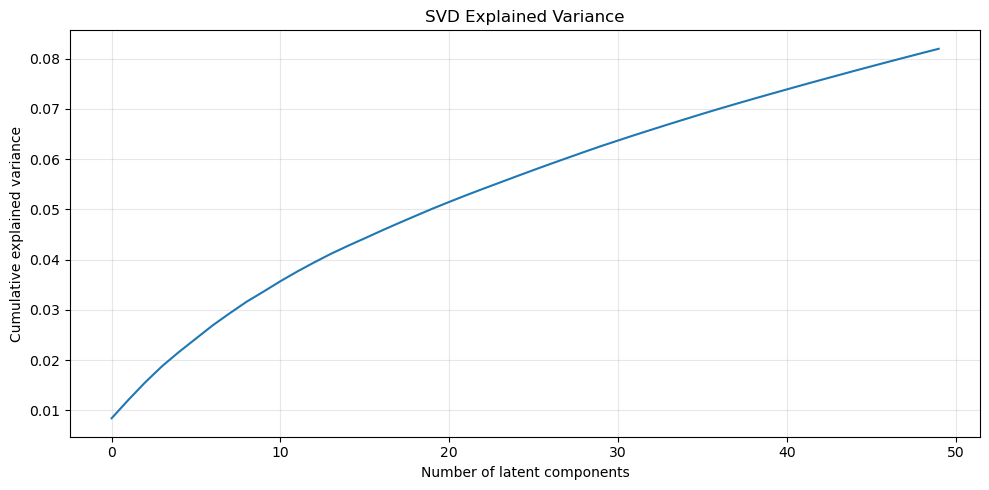

In [38]:
plt.figure(figsize=(10, 5))

plt.plot(np.cumsum(svd.explained_variance_ratio_))

plt.xlabel("Number of latent components")
plt.ylabel("Cumulative explained variance")
plt.title("SVD Explained Variance")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(FIGURE_DIR, "svd_explained_variance.png"), dpi=300)

plt.show()

In [39]:
global_mean = train_ratings["rating"].mean()

user_mean = (train_ratings.groupby("user_id")["rating"].mean())

In [40]:
def predict_rating(user_id, book_id):
    if (
        user_id not in user_to_index
        or book_id not in book_to_index
    ):
        return global_mean
    
    user_idx = user_to_index[user_id]
    book_idx = book_to_index[book_id]
    
    prediction = np.dot(
        user_factors[user_idx],
        book_factors[book_idx]
    )
    return prediction

In [41]:
test_eval = test_ratings[
    test_ratings["user_id"].isin(user_to_index)
    &
    test_ratings["book_id"].isin(book_to_index)
].copy()

In [42]:
test_eval["predicted_rating"] = [
    predict_rating(user_id, book_id)
    for user_id, book_id
    in zip(test_eval["user_id"], test_eval["book_id"])
]

In [43]:
test_eval["predicted_rating"] = (test_eval["predicted_rating"].clip(1, 5))

In [44]:
mae = mean_absolute_error(
    test_eval["rating"], test_eval["predicted_rating"]
)
rmse = np.sqrt(
    mean_squared_error(test_eval["rating"], test_eval["predicted_rating"])
)

print(f"Collaborative Filtering MAE: {mae:.4f}")
print(f"Collaborative Filtering RMSE: {rmse:.4f}")

Collaborative Filtering MAE: 2.8041
Collaborative Filtering RMSE: 2.9733


In [45]:
book_popularity = (
    ratings_cf.groupby("book_id").size().reset_index(name="interaction_count"
    )
)

In [46]:
book_popularity["popularity_score"] = (
    np.log1p(book_popularity["interaction_count"])
)

book_popularity["popularity_score"] /= (
    book_popularity["popularity_score"].max()
)

In [47]:
to_read_counts = (
    to_read.groupby("book_id").size().reset_index(
        name="to_read_count"
    )
)

In [48]:
book_popularity = book_popularity.merge(
    to_read_counts, on="book_id", how="left"
)

book_popularity["to_read_count"] = (
    book_popularity["to_read_count"].fillna(0)
)

In [49]:
book_popularity["to_read_score"] = (
    np.log1p(
        book_popularity["to_read_count"]
    )
)
max_to_read = (book_popularity["to_read_score"].max())

if max_to_read > 0:
    book_popularity["to_read_score"] /= max_to_read

In [50]:
book_popularity["popularity_score"] = (
    0.70 * book_popularity["popularity_score"]
    +
    0.30 * book_popularity["to_read_score"]
)

In [51]:
popularity_lookup = dict(
    zip(
        book_popularity["book_id"],
        book_popularity["popularity_score"]
    )
)

In [52]:
def recommend_collaborative(user_id, n=10):  
    if user_id not in user_to_index:
        return pd.DataFrame()
    
    user_idx = user_to_index[user_id]
    predicted_scores = (user_factors[user_idx]@book_factors.T)
    
    rated_books = set(
        train_ratings[train_ratings["user_id"] == user_id]["book_id"]
    )
    candidate_scores = []
    
    for idx, score in enumerate(predicted_scores):
        book_id = index_to_book[idx]
        
        if book_id not in rated_books:
            candidate_scores.append((book_id, score))
    
    candidate_scores.sort(key=lambda x: x[1], reverse=True)
    candidate_scores = candidate_scores[:n]
    
    result = pd.DataFrame(candidate_scores, columns=["book_id", "cf_score"])
    result = result.merge(
        books[["book_id", "Title", "Author"]], on="book_id", how="left"
    )
    
    return result   

In [53]:
sample_user = train_ratings.iloc[0]["user_id"]

recommend_collaborative(sample_user, n=10)

,book_id,cf_score,Title,Author
0,267,0.583222,The Nightingale,Kristin Hannah
1,262,0.529972,Big Little Lies,Liane Moriarty
2,112,0.518347,"Me Before You (Me Before You, #1)",Jojo Moyes
3,459,0.507464,A Man Called Ove,"Fredrik Backman, Henning Koch"
4,318,0.495877,Orphan Train,Christina Baker Kline
5,235,0.490367,The Husband's Secret,Liane Moriarty
6,993,0.488264,Tell the Wolves I'm Home,Carol Rifka Brunt
7,940,0.482576,One Plus One,Jojo Moyes
8,437,0.478021,The Invention of Wings,Sue Monk Kidd
9,359,0.467353,And the Mountains Echoed,Khaled Hosseini


In [54]:
def get_user_liked_books(user_id, min_rating=4):
    
    return train_ratings[
        (train_ratings["user_id"] == user_id)
        &
        (train_ratings["rating"] >= min_rating)
    ]["book_id"].tolist()

In [55]:
def get_content_scores(user_id):  
    liked_books = get_user_liked_books(user_id)
    
    if len(liked_books) == 0:
        return {}
    
    liked_indices = [book_index[book_id] for book_id in liked_books if book_id in book_index]
    if len(liked_indices) == 0:
        return {}
        
    user_profile = np.asarray(tfidf_matrix[liked_indices].mean(axis=0)) 
    content_scores = cosine_similarity(user_profile, tfidf_matrix).flatten()
    
    return {
        books.iloc[i]["book_id"]: content_scores[i]
        for i in range(len(books))
    }

In [56]:
def recommend_hybrid(user_id, n=10, cf_weight=0.60, content_weight=0.30, popularity_weight=0.10):
    
    if user_id not in user_to_index:
        return pd.DataFrame()
    
    user_idx = user_to_index[user_id]
    
# Collaborative scores
    cf_scores = (user_factors[user_idx]@book_factors.T)
    
    cf_lookup = {
        index_to_book[i]: cf_scores[i]
        for i in range(len(cf_scores))
    }
    
# Content scores
    content_lookup = get_content_scores(user_id)
    
# Books already rated
    rated_books = set(
        train_ratings[train_ratings["user_id"] == user_id]["book_id"]
    )
    
# Candidate books
    candidate_books = set(book_to_index.keys())
    candidate_books -= rated_books
    recommendations = []
    
    for book_id in candidate_books:
        if book_id not in cf_lookup:
            continue
        
        cf_score = cf_lookup.get(book_id, 0)
        
        content_score = content_lookup.get(book_id, 0)
        
        popularity_score = popularity_lookup.get(book_id, 0)
        
        recommendations.append(
            {"book_id": book_id, "cf_score": cf_score,
             "content_score": content_score, "popularity_score": popularity_score
            }
        )
    result = pd.DataFrame(recommendations)
    
    if result.empty:
        return result
    
    # Normalize CF score
    cf_min = result["cf_score"].min()
    cf_max = result["cf_score"].max()
    
    if cf_max > cf_min:
        result["cf_score_norm"] = (
            (result["cf_score"] - cf_min) / (cf_max - cf_min)
        )
    else:
        result["cf_score_norm"] = 0
    
    result["content_score_norm"] = (result["content_score"].clip(0, 1))
    
    result["hybrid_score"] = (
        (cf_weight * result["cf_score_norm"]) +
        (content_weight * result["content_score_norm"]) +
        (popularity_weight * result["popularity_score"])
    )
    
    result = result.sort_values("hybrid_score", ascending=False)
    result = result.head(n)
    result = result.merge(
        books[["book_id", "Title", "Author", "AvgRating"]], on="book_id", how="left"
    )
    
    return result[
        ["book_id", "Title", "Author", "AvgRating", "cf_score_norm",
          "content_score_norm", "popularity_score", "hybrid_score"
        ]
    ]

In [57]:
recommendations = recommend_hybrid(sample_user, n=10)
display(recommendations)

,book_id,Title,Author,AvgRating,cf_score_norm,content_score_norm,popularity_score,hybrid_score
0,267,The Nightingale,Kristin Hannah,4.54,1.000000,0.000000,0.966857,0.696686
1,944,Desperation,Stephen King,3.80,0.732292,0.478594,0.861309,0.669084
2,1123,Skeleton Crew,Stephen King,3.93,0.816963,0.275832,0.856785,0.658606
3,262,Big Little Lies,Liane Moriarty,4.20,0.927111,0.014942,0.950668,0.655816
4,967,The Dark Half,Stephen King,3.74,0.766350,0.359281,0.860772,0.653672
5,112,"Me Before You (Me Before You, #1)",Jojo Moyes,4.27,0.911198,0.000000,0.958001,0.642519
6,2155,From a Buick 8,Stephen King,3.42,0.689255,0.478594,0.839595,0.641091
7,1139,The Tommyknockers,Stephen King,3.48,0.676892,0.478594,0.853656,0.635079
8,459,A Man Called Ove,"Fredrik Backman, Henning Koch",4.35,0.896302,0.000000,0.943535,0.632134
9,609,Cell,Stephen King,3.64,0.733891,0.337972,0.883905,0.630117


In [58]:
def cold_start_recommendations(n=10):
    result = (book_stats.sort_values("popularity_score", ascending=False).head(n).merge
              (
                  books[["book_id", "Title", "Author", "AvgRating"]
                      ], 
                  on="book_id", how="left"
              )
             )
    return result[
        ["book_id", "Title", "Author", "AvgRating", "popularity_score"]
    ]

In [59]:
def cold_start_recommendations(n=10):
    top_books = book_stats.sort_values("popularity_score", ascending=False).head(n)
    cols_to_drop = [
        col
        for col in ["Title", "Author", "AvgRating"]
        if col in top_books.columns
    ]
    if cols_to_drop:
        top_books = top_books.drop(columns=cols_to_drop)
    result = top_books.merge(
        books[["book_id", "Title", "Author", "AvgRating"]],on="book_id", how="left"
    )
    return result[["book_id", "Title", "Author", "AvgRating", "popularity_score"]]

cold_start_recommendations(10)

,book_id,Title,Author,AvgRating,popularity_score
0,6920,The Indispensable Calvin and Hobbes,Bill Watterson,4.73,4.314939
1,5207,The Days Are Just Packed: A Calvin and Hobbes Collection,Bill Watterson,4.68,4.314939
2,9566,Attack of the Deranged Mutant Killer Monster Snow Goons,Bill Watterson,4.72,4.314939
3,6361,There's Treasure Everywhere: A Calvin and Hobbes Collection,Bill Watterson,4.74,4.313364
4,3275,"Harry Potter Boxed Set, Books 1-5 (Harry Potter, #1-5)","J.K. Rowling, Mary GrandPré",4.77,4.313364
5,5580,The Calvin and Hobbes Lazy Sunday Book,Bill Watterson,4.66,4.303364
6,4483,It's a Magical World: A Calvin and Hobbes Collection,Bill Watterson,4.75,4.303364
7,6590,The Authoritative Calvin and Hobbes: A Calvin and Hobbes Treasury,Bill Watterson,4.73,4.303364
8,7947,ESV Study Bible,"Anonymous, Lane T. Dennis, Wayne A. Grudem",4.76,4.303063
9,1308,"A Court of Mist and Fury (A Court of Thorns and Roses, #2)",Sarah J. Maas,4.72,4.294838


In [60]:
def recommend_for_new_user(favorite_book_ids, n=10): 
    valid_indices = [
        book_index[book_id]
        for book_id in favorite_book_ids
        if book_id in book_index
    ]
    if len(valid_indices) == 0:
        return cold_start_recommendations(n)
    
    user_profile = np.asarray(tfidf_matrix[valid_indices].mean(axis=0))
    scores = cosine_similarity(user_profile, tfidf_matrix).flatten()
    
    favorite_set = set(favorite_book_ids)
    
    candidates = []
    
    for i, score in enumerate(scores):
        book_id = books.iloc[i]["book_id"]
        if book_id in favorite_set:
            continue
        
        candidates.append((book_id, score))
    candidates.sort(key=lambda x: x[1], reverse=True)
    candidates = candidates[:n]
    
    result = pd.DataFrame(candidates, columns=["book_id", "content_score"])
    
    result = result.merge(
        books[["book_id", "Title", "Author", "AvgRating"]],
        on="book_id", how="left"
    )    
    return result

In [61]:
favorite_books = books.head(3)["book_id"].tolist()

recommend_for_new_user(favorite_books, n=10)

,book_id,content_score,Title,Author,AvgRating
0,507,0.505422,"The Hunger Games Trilogy Boxset (The Hunger Games, #1-3)",Suzanne Collins,4.49
1,2021,0.498444,"The Twilight Collection (Twilight, #1-3)",Stephenie Meyer,3.78
2,24,0.491567,"Harry Potter and the Goblet of Fire (Harry Potter, #4)","J.K. Rowling, Mary GrandPré",4.53
3,52,0.482700,"Eclipse (Twilight, #3)",Stephenie Meyer,3.69
4,17,0.477408,"Catching Fire (The Hunger Games, #2)",Suzanne Collins,4.30
5,25,0.471233,"Harry Potter and the Deathly Hallows (Harry Potter, #7)","J.K. Rowling, Mary GrandPré",4.61
6,2101,0.460619,"The Harry Potter Collection 1-4 (Harry Potter, #1-4)","J.K. Rowling, Mary GrandPré",4.66
7,23,0.446977,"Harry Potter and the Chamber of Secrets (Harry Potter, #2)","J.K. Rowling, Mary GrandPré",4.37
8,27,0.444009,"Harry Potter and the Half-Blood Prince (Harry Potter, #6)","J.K. Rowling, Mary GrandPré",4.54
9,1619,0.443871,"The Twilight Saga Complete Collection (Twilight, #1-4 + 3.5)",Stephenie Meyer,4.31


In [62]:
def precision_at_k(recommended, relevant, k=10):  
    recommended = recommended[:k]
    
    if len(recommended) == 0:
        return 0
    
    hits = len(set(recommended)&set(relevant))
    return hits / len(recommended)

In [63]:
def recall_at_k(recommended, relevant, k=10):
    
    if len(relevant) == 0:
        return 0
    
    recommended = recommended[:k] 
    hits = len(set(recommended)&set(relevant))
    return hits / len(relevant)

In [64]:
def ndcg_at_k(recommended, relevant, k=10):  
    recommended = recommended[:k]
    dcg = 0.0
    
    for i, item in enumerate(recommended): 
        if item in relevant:
            dcg += ( 1 / np.log2(i + 2))
    
    ideal_hits = min(len(relevant), k)
    if ideal_hits == 0:
        return 0
    
    idcg = sum(1 / np.log2(i + 2) for i in range(ideal_hits))
    
    return dcg / idcg

In [65]:
eligible_eval_users = (test_ratings.groupby("user_id").size())

eligible_eval_users = (eligible_eval_users[eligible_eval_users >= 1].index)
evaluation_users = (
    pd.Series(eligible_eval_users).sample(
        min(500, len(eligible_eval_users)), random_state=42
    ).tolist()
)

In [66]:
precision_scores = []
recall_scores = []
ndcg_scores = []

for user_id in evaluation_users:
    relevant_books = test_ratings[(test_ratings["user_id"] == user_id) 
        & (test_ratings["rating"] >= 4)]["book_id"].tolist()
    
    if len(relevant_books) == 0:
        continue
    
    recs = recommend_hybrid(user_id, n=10)
    if recs.empty:
        continue
    
    recommended_books = (recs["book_id"].tolist())
    precision_scores.append(precision_at_k(recommended_books, relevant_books, 10)) 
   
    recall_scores.append(recall_at_k(recommended_books, relevant_books, 10)) 
    
    ndcg_scores.append(ndcg_at_k(recommended_books, relevant_books, 10))

In [67]:
hybrid_precision = np.mean(precision_scores)

hybrid_recall = np.mean(recall_scores)

hybrid_ndcg = np.mean(ndcg_scores)

print(f"Hybrid Precision@10: {hybrid_precision:.4f}")
print(f"Hybrid Recall@10: {hybrid_recall:.4f}")
print(f"Hybrid NDCG@10: {hybrid_ndcg:.4f}")

Hybrid Precision@10: 0.0378
Hybrid Recall@10: 0.0741
Hybrid NDCG@10: 0.0711


In [68]:
if (hybrid_precision + hybrid_recall) > 0: 
    hybrid_f1 = (2 * hybrid_precision * hybrid_recall 
                 / (hybrid_precision + hybrid_recall)
    ) 
else:
    hybrid_f1 = 0

print(f"Hybrid F1@10: {hybrid_f1:.4f}")

Hybrid F1@10: 0.0501


In [69]:
evaluation_results = pd.DataFrame(
    {
        "Model": ["Popularity Baseline", "Content-Based", "Collaborative Filtering", "Hybrid"],
        "RMSE": [np.nan, np.nan, rmse, np.nan],
        "MAE": [np.nan, np.nan, mae, np.nan],
        "Precision@10": [np.nan, np.nan, np.nan, hybrid_precision],
        "Recall@10": [np.nan, np.nan, np.nan, hybrid_recall],
        "F1@10": [np.nan, np.nan, np.nan, hybrid_f1],
        "NDCG@10": [np.nan, np.nan, np.nan, hybrid_ndcg]
    }
)
display(evaluation_results)

,Model,RMSE,MAE,Precision@10,Recall@10,F1@10,NDCG@10
0,Popularity Baseline,NaN,NaN,NaN,NaN,NaN,NaN
1,Content-Based,NaN,NaN,NaN,NaN,NaN,NaN
2,Collaborative Filtering,2.973328,2.804148,NaN,NaN,NaN,NaN
3,Hybrid,NaN,NaN,0.037783,0.074116,0.050051,0.071104


In [70]:
evaluation_results.to_csv(
    os.path.join(EVALUATION_DIR, "model_evaluation.csv"), index=False)

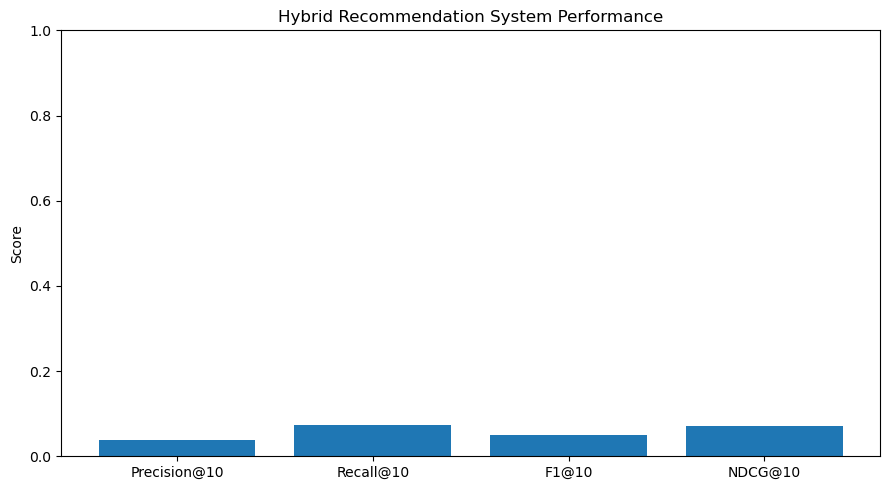

In [71]:
metrics_to_plot = ["Precision@10", "Recall@10", "F1@10", "NDCG@10"]

hybrid_metrics = [hybrid_precision, hybrid_recall, hybrid_f1, hybrid_ndcg]

plt.figure(figsize=(9, 5))

plt.bar(
    metrics_to_plot,
    hybrid_metrics
)

plt.title("Hybrid Recommendation System Performance")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "hybrid_performance.png"), dpi=300)

plt.show()

In [72]:
weight_configurations = [
    (0.80, 0.10, 0.10),
    (0.70, 0.20, 0.10),
    (0.60, 0.30, 0.10),
    (0.50, 0.40, 0.10),
    (0.50, 0.30, 0.20),
    (0.40, 0.40, 0.20)
]

In [73]:
def recommend_books(user_id=None, favorite_book_ids=None, n=10):
    if user_id is not None:
        if user_id in user_to_index:
            return recommend_hybrid(user_id, n=n)
    
    if favorite_book_ids is not None:
        return recommend_for_new_user(favorite_book_ids,n=n) 
    
    return cold_start_recommendations(n)

In [74]:
recommend_books(user_id=sample_user, n=10)

,book_id,Title,Author,AvgRating,cf_score_norm,content_score_norm,popularity_score,hybrid_score
0,267,The Nightingale,Kristin Hannah,4.54,1.000000,0.000000,0.966857,0.696686
1,944,Desperation,Stephen King,3.80,0.732292,0.478594,0.861309,0.669084
2,1123,Skeleton Crew,Stephen King,3.93,0.816963,0.275832,0.856785,0.658606
3,262,Big Little Lies,Liane Moriarty,4.20,0.927111,0.014942,0.950668,0.655816
4,967,The Dark Half,Stephen King,3.74,0.766350,0.359281,0.860772,0.653672
5,112,"Me Before You (Me Before You, #1)",Jojo Moyes,4.27,0.911198,0.000000,0.958001,0.642519
6,2155,From a Buick 8,Stephen King,3.42,0.689255,0.478594,0.839595,0.641091
7,1139,The Tommyknockers,Stephen King,3.48,0.676892,0.478594,0.853656,0.635079
8,459,A Man Called Ove,"Fredrik Backman, Henning Koch",4.35,0.896302,0.000000,0.943535,0.632134
9,609,Cell,Stephen King,3.64,0.733891,0.337972,0.883905,0.630117


In [75]:
favorite_book_ids = books.iloc[:3]["book_id"].tolist()

recommend_books(favorite_book_ids=favorite_book_ids, n=10)

,book_id,content_score,Title,Author,AvgRating
0,507,0.505422,"The Hunger Games Trilogy Boxset (The Hunger Games, #1-3)",Suzanne Collins,4.49
1,2021,0.498444,"The Twilight Collection (Twilight, #1-3)",Stephenie Meyer,3.78
2,24,0.491567,"Harry Potter and the Goblet of Fire (Harry Potter, #4)","J.K. Rowling, Mary GrandPré",4.53
3,52,0.482700,"Eclipse (Twilight, #3)",Stephenie Meyer,3.69
4,17,0.477408,"Catching Fire (The Hunger Games, #2)",Suzanne Collins,4.30
5,25,0.471233,"Harry Potter and the Deathly Hallows (Harry Potter, #7)","J.K. Rowling, Mary GrandPré",4.61
6,2101,0.460619,"The Harry Potter Collection 1-4 (Harry Potter, #1-4)","J.K. Rowling, Mary GrandPré",4.66
7,23,0.446977,"Harry Potter and the Chamber of Secrets (Harry Potter, #2)","J.K. Rowling, Mary GrandPré",4.37
8,27,0.444009,"Harry Potter and the Half-Blood Prince (Harry Potter, #6)","J.K. Rowling, Mary GrandPré",4.54
9,1619,0.443871,"The Twilight Saga Complete Collection (Twilight, #1-4 + 3.5)",Stephenie Meyer,4.31


In [76]:
recommend_books(n=10)

,book_id,Title,Author,AvgRating,popularity_score
0,6920,The Indispensable Calvin and Hobbes,Bill Watterson,4.73,4.314939
1,5207,The Days Are Just Packed: A Calvin and Hobbes Collection,Bill Watterson,4.68,4.314939
2,9566,Attack of the Deranged Mutant Killer Monster Snow Goons,Bill Watterson,4.72,4.314939
3,6361,There's Treasure Everywhere: A Calvin and Hobbes Collection,Bill Watterson,4.74,4.313364
4,3275,"Harry Potter Boxed Set, Books 1-5 (Harry Potter, #1-5)","J.K. Rowling, Mary GrandPré",4.77,4.313364
5,5580,The Calvin and Hobbes Lazy Sunday Book,Bill Watterson,4.66,4.303364
6,4483,It's a Magical World: A Calvin and Hobbes Collection,Bill Watterson,4.75,4.303364
7,6590,The Authoritative Calvin and Hobbes: A Calvin and Hobbes Treasury,Bill Watterson,4.73,4.303364
8,7947,ESV Study Bible,"Anonymous, Lane T. Dennis, Wayne A. Grudem",4.76,4.303063
9,1308,"A Court of Mist and Fury (A Court of Thorns and Roses, #2)",Sarah J. Maas,4.72,4.294838


In [77]:
final_recommendations = recommend_books(user_id=sample_user, n=10)

final_recommendations.to_csv(
    os.path.join(RECOMMENDATION_DIR, "final_recommendations.csv"), index=False
)

display(final_recommendations)

,book_id,Title,Author,AvgRating,cf_score_norm,content_score_norm,popularity_score,hybrid_score
0,267,The Nightingale,Kristin Hannah,4.54,1.000000,0.000000,0.966857,0.696686
1,944,Desperation,Stephen King,3.80,0.732292,0.478594,0.861309,0.669084
2,1123,Skeleton Crew,Stephen King,3.93,0.816963,0.275832,0.856785,0.658606
3,262,Big Little Lies,Liane Moriarty,4.20,0.927111,0.014942,0.950668,0.655816
4,967,The Dark Half,Stephen King,3.74,0.766350,0.359281,0.860772,0.653672
5,112,"Me Before You (Me Before You, #1)",Jojo Moyes,4.27,0.911198,0.000000,0.958001,0.642519
6,2155,From a Buick 8,Stephen King,3.42,0.689255,0.478594,0.839595,0.641091
7,1139,The Tommyknockers,Stephen King,3.48,0.676892,0.478594,0.853656,0.635079
8,459,A Man Called Ove,"Fredrik Backman, Henning Koch",4.35,0.896302,0.000000,0.943535,0.632134
9,609,Cell,Stephen King,3.64,0.733891,0.337972,0.883905,0.630117
